# Système de recommandation de livres pour une bibliothèque universitaire

**Projet Data Mining + DSS**

Objectif : recommander des livres aux étudiants à partir des historiques de ratings, puis aider la bibliothèque à prendre des décisions : quels livres recommander, quels profils d'étudiants existent, quelles catégories renforcer.

Pipeline : compréhension du problème → données → prétraitement → modélisation → évaluation → DSS → visualisation.

## 1. Importation des bibliothèques

In [1]:
import warnings
warnings.simplefilter(action='ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.set_option('display.expand_frame_repr', False)

## 2. Chargement des données

Le notebook cherche d'abord les fichiers Kaggle dans `data/raw/`. Si les fichiers n'existent pas, il utilise les données simulées dans `data/sample/` pour tester le projet.

In [2]:
BASE_DIR = Path('..') if Path('../data').exists() else Path('.')
RAW_DIR = BASE_DIR / 'data' / 'raw'
SAMPLE_DIR = BASE_DIR / 'data' / 'sample'
OUTPUT_DIR = BASE_DIR / 'outputs'
FIG_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

def find_file(filename):
    for folder in [RAW_DIR, SAMPLE_DIR, BASE_DIR]:
        path = folder / filename
        if path.exists():
            return path
    raise FileNotFoundError(f"{filename} introuvable. Place le fichier dans data/raw/.")

def read_csv_smart(path):
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='latin-1')

books = read_csv_smart(find_file('Books.csv'))
ratings = read_csv_smart(find_file('Ratings.csv'))
users = read_csv_smart(find_file('Users.csv'))

print('Books:', books.shape)
print('Ratings:', ratings.shape)
print('Users:', users.shape)

Books: (12, 8)
Ratings: (130, 3)
Users: (20, 3)


## 3. Aperçu des données

In [3]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,9780001,Python pour Débutants,M. Alaoui,2020,FST Press,NaN,NaN,NaN
1,9780002,Data Mining Concepts,J. Han,2019,Academic Press,NaN,NaN,NaN
2,9780003,Machine Learning avec Python,A. Géron,2021,OReilly,NaN,NaN,NaN
3,9780004,Base de Données SQL,K. Bennis,2018,Campus,NaN,NaN,NaN
4,9780005,Réseaux Informatiques Cisco,N. Tazi,2022,NetworkLab,NaN,NaN,NaN


In [4]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,1,9780001,8
1,1,9780002,9
2,1,9780003,7
3,1,9780006,3
4,1,9780009,7


In [5]:
users.head()

,User-ID,Location,Age
0,1,"Tanger, Maroc",21
1,2,"Tanger, Maroc",22
2,3,"Tanger, Maroc",20
3,4,"Tanger, Maroc",22
4,5,"Tanger, Maroc",24


## 4. Qualité des données

On vérifie les valeurs manquantes, les types et les doublons. Cette étape correspond à la compréhension + qualité des données dans le pipeline Data Mining.

In [6]:
print('--- Books info ---')
books.info()
print('\n--- Ratings info ---')
ratings.info()
print('\n--- Users info ---')
users.info()

--- Books info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ISBN                 12 non-null     int64  
 1   Book-Title           12 non-null     object 
 2   Book-Author          12 non-null     object 
 3   Year-Of-Publication  12 non-null     int64  
 4   Publisher            12 non-null     object 
 5   Image-URL-S          0 non-null      float64
 6   Image-URL-M          0 non-null      float64
 7   Image-URL-L          0 non-null      float64
dtypes: float64(3), int64(2), object(3)
memory usage: 900.0+ bytes

--- Ratings info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   User-ID      130 non-null    int64
 1   ISBN         130 non-null    int64
 2   Book-Rating  130 non-

In [7]:
quality = pd.DataFrame({
    'table': ['books', 'ratings', 'users'],
    'rows': [len(books), len(ratings), len(users)],
    'duplicates': [books.duplicated().sum(), ratings.duplicated().sum(), users.duplicated().sum()],
    'missing_values': [books.isnull().sum().sum(), ratings.isnull().sum().sum(), users.isnull().sum().sum()]
})
quality

,table,rows,duplicates,missing_values
0,books,12,0,36
1,ratings,130,0,0
2,users,20,0,0


## 5. Prétraitement

Dans le dataset Kaggle, `Book-Rating = 0` représente souvent une interaction implicite. Pour l'évaluation RMSE, on garde les ratings explicites entre 1 et 10.

In [8]:
books_clean = books.drop_duplicates(subset=['ISBN']).copy()

if 'Year-Of-Publication' in books_clean.columns:
    books_clean['Year-Of-Publication'] = pd.to_numeric(books_clean['Year-Of-Publication'], errors='coerce')
    books_clean.loc[(books_clean['Year-Of-Publication'] < 1900) | (books_clean['Year-Of-Publication'] > 2026), 'Year-Of-Publication'] = np.nan

ratings_clean = ratings.drop_duplicates().copy()
ratings_clean['Book-Rating'] = pd.to_numeric(ratings_clean['Book-Rating'], errors='coerce')
ratings_clean = ratings_clean.dropna(subset=['User-ID', 'ISBN', 'Book-Rating'])
ratings_explicit = ratings_clean[(ratings_clean['Book-Rating'] >= 1) & (ratings_clean['Book-Rating'] <= 10)].copy()

print('Books clean:', books_clean.shape)
print('Ratings explicit:', ratings_explicit.shape)

Books clean: (12, 8)
Ratings explicit: (130, 3)


## 6. Analyse exploratoire EDA

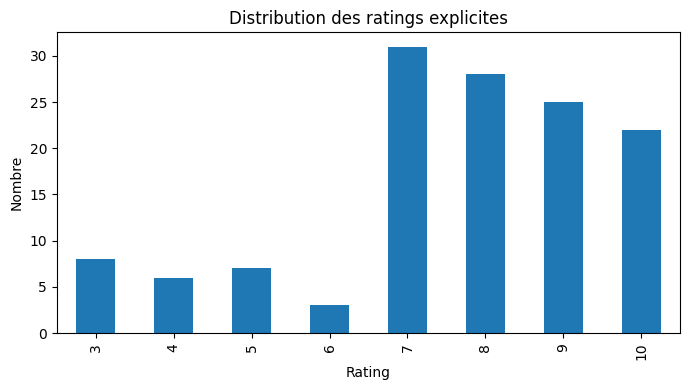

In [9]:
plt.figure(figsize=(7,4))
ratings_explicit['Book-Rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution des ratings explicites')
plt.xlabel('Rating')
plt.ylabel('Nombre')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ratings_distribution.png')
plt.show()

In [10]:
book_popularity = ratings_explicit.groupby('ISBN')['Book-Rating'].agg(['count','mean']).reset_index()
book_popularity = book_popularity.merge(books_clean[['ISBN','Book-Title','Book-Author']], on='ISBN', how='left')
top_books = book_popularity.sort_values('count', ascending=False).head(10)
top_books

,ISBN,count,mean,Book-Title,Book-Author
0,9780001,17,8.000000,Python pour Débutants,M. Alaoui
1,9780002,15,8.200000,Data Mining Concepts,J. Han
3,9780004,15,7.400000,Base de Données SQL,K. Bennis
5,9780006,12,6.833333,Cybersécurité Fondamentale,S. Amrani
11,9780012,10,7.600000,Analyse et Conception UML,D. Robert
6,9780007,10,7.600000,Développement Web Laravel,Y. El Fassi
2,9780003,9,7.777778,Machine Learning avec Python,A. Géron
7,9780008,9,7.888889,Java Programmation Orientée Objet,R. Martin
9,9780010,9,7.111111,Statistiques pour Data Science,L. Cohen
8,9780009,9,7.111111,Intelligence Artificielle,P. Russell


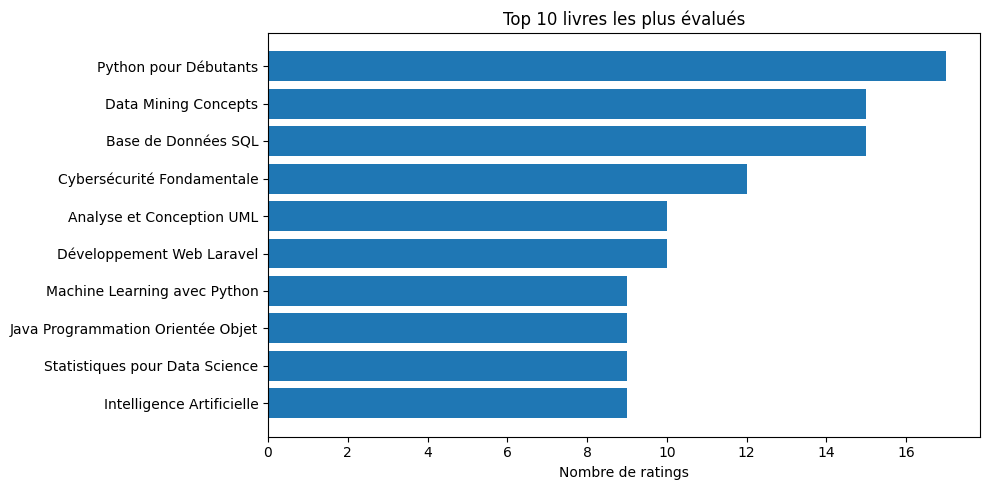

In [11]:
plt.figure(figsize=(10,5))
plt.barh(top_books['Book-Title'].fillna(top_books['ISBN']).astype(str)[::-1], top_books['count'][::-1])
plt.title('Top 10 livres les plus évalués')
plt.xlabel('Nombre de ratings')
plt.tight_layout()
plt.savefig(FIG_DIR / 'top_books.png')
plt.show()

## 7. Création de la matrice utilisateur-livre

Les lignes représentent les étudiants/utilisateurs, les colonnes représentent les livres, et les valeurs représentent les ratings.

Cette matrice est le cœur du filtrage collaboratif.

In [12]:
# Paramètres adaptables selon la taille du dataset
MIN_USER_RATINGS = 5
MIN_BOOK_RATINGS = 5
MAX_USERS = 3000
MAX_BOOKS = 3000

user_counts = ratings_explicit['User-ID'].value_counts()
book_counts = ratings_explicit['ISBN'].value_counts()

active_users = user_counts[user_counts >= MIN_USER_RATINGS].index
popular_books = book_counts[book_counts >= MIN_BOOK_RATINGS].index

filtered_ratings = ratings_explicit[
    ratings_explicit['User-ID'].isin(active_users) &
    ratings_explicit['ISBN'].isin(popular_books)
].copy()

# Sécurité pour grands datasets
selected_users = filtered_ratings['User-ID'].value_counts().head(MAX_USERS).index
selected_books = filtered_ratings['ISBN'].value_counts().head(MAX_BOOKS).index
filtered_ratings = filtered_ratings[
    filtered_ratings['User-ID'].isin(selected_users) &
    filtered_ratings['ISBN'].isin(selected_books)
]

user_book_matrix = filtered_ratings.pivot_table(
    index='User-ID',
    columns='ISBN',
    values='Book-Rating',
    aggfunc='mean'
)

print('Filtered ratings:', filtered_ratings.shape)
print('User-book matrix:', user_book_matrix.shape)
user_book_matrix.head()

Filtered ratings: (130, 3)
User-book matrix: (20, 12)


ISBN,9780001,9780002,9780003,9780004,9780005,9780006,9780007,9780008,9780009,9780010,9780011,9780012
User-ID,,,,,,,,,,,,
1,8.0,9.0,7.0,NaN,NaN,3.0,NaN,NaN,7.0,8.0,NaN,NaN
2,8.0,NaN,NaN,7.0,NaN,NaN,9.0,8.0,5.0,NaN,NaN,9.0
3,7.0,9.0,NaN,8.0,8.0,8.0,NaN,7.0,NaN,5.0,9.0,NaN
4,8.0,10.0,10.0,NaN,NaN,5.0,NaN,NaN,7.0,7.0,NaN,NaN
5,10.0,NaN,4.0,7.0,NaN,6.0,9.0,8.0,NaN,NaN,NaN,8.0


## 8. Modèle 1 - Filtrage collaboratif Item-Based

Idée : deux livres sont similaires s'ils sont aimés par les mêmes utilisateurs.

In [13]:
filled_matrix = user_book_matrix.fillna(0)
item_similarity = cosine_similarity(filled_matrix.T)
item_similarity_df = pd.DataFrame(item_similarity, index=filled_matrix.columns, columns=filled_matrix.columns)
item_similarity_df.iloc[:5, :5]

ISBN,9780001,9780002,9780003,9780004,9780005
ISBN,,,,,
9780001,1.000000,0.692209,0.745990,0.624772,0.218110
9780002,0.692209,1.000000,0.737157,0.631049,0.582833
9780003,0.745990,0.737157,1.000000,0.175265,0.000000
9780004,0.624772,0.631049,0.175265,1.000000,0.764804
9780005,0.218110,0.582833,0.000000,0.764804,1.000000


In [14]:
def recommend_similar_books_by_title(title_keyword, top_n=10):
    matches = books_clean[books_clean['Book-Title'].astype(str).str.contains(title_keyword, case=False, na=False)]
    matches = matches[matches['ISBN'].isin(item_similarity_df.index)]
    if matches.empty:
        return pd.DataFrame({'message': [f'Aucun livre trouvé avec: {title_keyword}']})
    isbn = matches.iloc[0]['ISBN']
    similar_scores = item_similarity_df[isbn].sort_values(ascending=False).drop(isbn).head(top_n)
    recs = similar_scores.reset_index()
    recs.columns = ['ISBN', 'similarity']
    recs = recs.merge(books_clean[['ISBN','Book-Title','Book-Author']], on='ISBN', how='left')
    return recs

# Exemple : changer le mot-clé selon les titres disponibles
example_title = str(books_clean[books_clean['ISBN'].isin(item_similarity_df.index)].iloc[0]['Book-Title'])
print('Livre exemple:', example_title)
recommend_similar_books_by_title(example_title[:10], top_n=10)

Livre exemple: Python pour Débutants


,ISBN,similarity,Book-Title,Book-Author
0,9780008,0.746629,Java Programmation Orientée Objet,R. Martin
1,9780003,0.745990,Machine Learning avec Python,A. Géron
2,9780010,0.733497,Statistiques pour Data Science,L. Cohen
3,9780012,0.719243,Analyse et Conception UML,D. Robert
4,9780009,0.694527,Intelligence Artificielle,P. Russell
5,9780002,0.692209,Data Mining Concepts,J. Han
6,9780007,0.675259,Développement Web Laravel,Y. El Fassi
7,9780004,0.624772,Base de Données SQL,K. Bennis
8,9780006,0.444513,Cybersécurité Fondamentale,S. Amrani
9,9780011,0.232204,Systèmes d Exploitation Linux,H. Benali


## 9. Modèle 2 - Filtrage collaboratif User-Based

Idée : si deux étudiants ont des goûts similaires, on peut recommander à l'un les livres aimés par l'autre.

In [15]:
user_similarity = cosine_similarity(filled_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=filled_matrix.index, columns=filled_matrix.index)
user_similarity_df.iloc[:5, :5]

User-ID,1,2,3,4,5
User-ID,,,,,
1,1.000000,0.291905,0.517718,0.983693,0.350054
2,0.291905,1.000000,0.403180,0.263772,0.895640
3,0.517718,0.403180,1.000000,0.514372,0.520088
4,0.983693,0.263772,0.514372,1.000000,0.376568
5,0.350054,0.895640,0.520088,0.376568,1.000000


In [16]:
def recommend_books_for_user(user_id, top_n=10, n_neighbors=20):
    if user_id not in filled_matrix.index:
        return pd.DataFrame({'message': [f'Utilisateur {user_id} introuvable dans la matrice']})

    neighbors = user_similarity_df[user_id].drop(user_id).sort_values(ascending=False).head(n_neighbors)
    neighbor_ratings = filled_matrix.loc[neighbors.index]
    weighted_scores = np.dot(neighbors.values, neighbor_ratings) / (np.abs(neighbors.values).sum() + 1e-9)
    scores = pd.Series(weighted_scores, index=filled_matrix.columns)

    already_rated = filled_matrix.loc[user_id]
    scores = scores[already_rated == 0].sort_values(ascending=False).head(top_n)

    recs = scores.reset_index()
    recs.columns = ['ISBN', 'recommendation_score']
    recs = recs.merge(books_clean[['ISBN','Book-Title','Book-Author']], on='ISBN', how='left')
    return recs

example_user = filled_matrix.index[0]
print('Utilisateur exemple:', example_user)
user_recommendations = recommend_books_for_user(example_user, top_n=10)
user_recommendations

Utilisateur exemple: 1


,ISBN,recommendation_score,Book-Title,Book-Author
0,9780004,4.116774,Base de Données SQL,K. Bennis
1,9780012,2.802833,Analyse et Conception UML,D. Robert
2,9780008,2.576329,Java Programmation Orientée Objet,R. Martin
3,9780011,2.409199,Systèmes d Exploitation Linux,H. Benali
4,9780007,2.398580,Développement Web Laravel,Y. El Fassi
5,9780005,1.842314,Réseaux Informatiques Cisco,N. Tazi


## 10. Évaluation - RMSE

On compare des modèles simples de prédiction de rating : moyenne globale, moyenne par utilisateur et moyenne par livre. Plus le RMSE est petit, meilleure est la prédiction.

In [17]:
train, test = train_test_split(ratings_explicit, test_size=0.2, random_state=42)

global_mean = train['Book-Rating'].mean()
user_mean = train.groupby('User-ID')['Book-Rating'].mean()
item_mean = train.groupby('ISBN')['Book-Rating'].mean()

pred_global = np.full(len(test), global_mean)
pred_user = test['User-ID'].map(user_mean).fillna(global_mean)
pred_item = test['ISBN'].map(item_mean).fillna(global_mean)

rmse_global = np.sqrt(mean_squared_error(test['Book-Rating'], pred_global))
rmse_user = np.sqrt(mean_squared_error(test['Book-Rating'], pred_user))
rmse_item = np.sqrt(mean_squared_error(test['Book-Rating'], pred_item))

rmse_results = pd.DataFrame({
    'Model': ['Global Mean', 'User Mean', 'Item Mean'],
    'RMSE': [rmse_global, rmse_user, rmse_item]
}).sort_values('RMSE')

rmse_results.to_csv(TABLE_DIR / 'rmse_results.csv', index=False)
rmse_results

,Model,RMSE
0,Global Mean,1.809763
1,User Mean,1.927577
2,Item Mean,2.070071


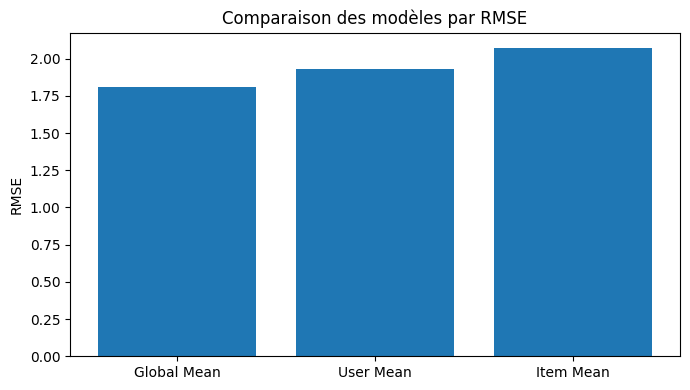

In [18]:
plt.figure(figsize=(7,4))
plt.bar(rmse_results['Model'], rmse_results['RMSE'])
plt.title('Comparaison des modèles par RMSE')
plt.ylabel('RMSE')
plt.tight_layout()
plt.savefig(FIG_DIR / 'rmse_comparison.png')
plt.show()

## 11. Évaluation - Precision@K et Hit Rate@K

On cache un livre aimé par utilisateur, puis on vérifie si le système le recommande dans le Top K.

In [19]:
def evaluate_precision_hit_rate(k=10, max_eval_users=200):
    # utilisateurs avec assez de ratings pour cacher un item
    user_groups = filtered_ratings.groupby('User-ID')
    eligible_users = [u for u, g in user_groups if len(g) >= 3]
    eligible_users = eligible_users[:max_eval_users]

    hits = 0
    evaluated = 0
    for user in eligible_users:
        user_data = filtered_ratings[filtered_ratings['User-ID'] == user]
        # On considère comme pertinent un livre avec rating >= 7
        relevant = user_data[user_data['Book-Rating'] >= 7]
        if relevant.empty:
            continue
        hidden_isbn = relevant.sample(1, random_state=42)['ISBN'].iloc[0]
        recs = recommend_books_for_user(user, top_n=k)
        if 'ISBN' not in recs.columns:
            continue
        recommended_isbns = set(recs['ISBN'].tolist())
        if hidden_isbn in recommended_isbns:
            hits += 1
        evaluated += 1

    precision_at_k = hits / (evaluated * k) if evaluated else 0
    hit_rate_at_k = hits / evaluated if evaluated else 0
    return pd.DataFrame({'K':[k], 'Evaluated users':[evaluated], 'Hits':[hits], 'Precision@K':[precision_at_k], 'HitRate@K':[hit_rate_at_k]})

precision_results = evaluate_precision_hit_rate(k=10)
precision_results.to_csv(TABLE_DIR / 'precision_hit_rate.csv', index=False)
precision_results

,K,Evaluated users,Hits,Precision@K,HitRate@K
0,10,20,0,0.0,0.0


## 12. Clustering - K-Means

Objectif : segmenter les étudiants selon leurs habitudes de lecture. On réduit d'abord la dimension avec SVD, puis on applique K-Means.

In [20]:
N_CLUSTERS = 4
n_components = min(20, max(2, min(filled_matrix.shape) - 1))

if min(filled_matrix.shape) > 2:
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    user_features = svd.fit_transform(filled_matrix)
else:
    user_features = filled_matrix.values

kmeans = KMeans(n_clusters=min(N_CLUSTERS, len(filled_matrix)), random_state=42, n_init=10)
clusters = kmeans.fit_predict(user_features)

user_clusters = pd.DataFrame({'User-ID': filled_matrix.index, 'Cluster': clusters})
user_clusters.to_csv(TABLE_DIR / 'user_clusters.csv', index=False)

silhouette = None
if len(set(clusters)) > 1 and len(clusters) > len(set(clusters)):
    silhouette = silhouette_score(user_features, clusters)

print('Silhouette score:', silhouette)
user_clusters.head()

Silhouette score: 0.5182659465919274


,User-ID,Cluster
0,1,1
1,2,0
2,3,2
3,4,1
4,5,0


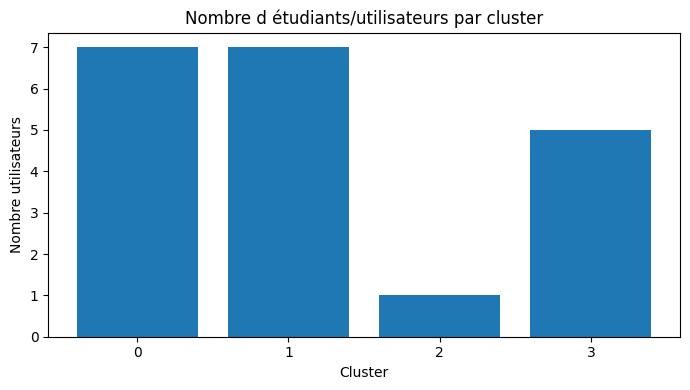

Cluster
0    7
1    7
2    1
3    5
Name: count, dtype: int64

In [21]:
cluster_counts = user_clusters['Cluster'].value_counts().sort_index()
plt.figure(figsize=(7,4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title('Nombre d étudiants/utilisateurs par cluster')
plt.xlabel('Cluster')
plt.ylabel('Nombre utilisateurs')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cluster_distribution.png')
plt.show()
cluster_counts

## 13. Interprétation des clusters

Pour interpréter chaque cluster, on regarde les livres les plus notés par les utilisateurs de ce cluster.

In [22]:
cluster_interpretation = []
for cluster_id in sorted(user_clusters['Cluster'].unique()):
    users_in_cluster = user_clusters[user_clusters['Cluster'] == cluster_id]['User-ID']
    cluster_ratings = filtered_ratings[filtered_ratings['User-ID'].isin(users_in_cluster)]
    top_cluster_books = (cluster_ratings.groupby('ISBN')['Book-Rating']
                         .agg(['count','mean'])
                         .sort_values(['count','mean'], ascending=False)
                         .head(5)
                         .reset_index()
                         .merge(books_clean[['ISBN','Book-Title','Book-Author']], on='ISBN', how='left'))
    for _, row in top_cluster_books.iterrows():
        cluster_interpretation.append({
            'Cluster': cluster_id,
            'ISBN': row['ISBN'],
            'Book-Title': row.get('Book-Title', ''),
            'Book-Author': row.get('Book-Author', ''),
            'Ratings count': row['count'],
            'Average rating': row['mean']
        })

cluster_interpretation_df = pd.DataFrame(cluster_interpretation)
cluster_interpretation_df.to_csv(TABLE_DIR / 'cluster_interpretation.csv', index=False)
cluster_interpretation_df

,Cluster,ISBN,Book-Title,Book-Author,Ratings count,Average rating
0,0,9780007,Développement Web Laravel,Y. El Fassi,7,9.142857
1,0,9780001,Python pour Débutants,M. Alaoui,7,8.857143
2,0,9780008,Java Programmation Orientée Objet,R. Martin,7,8.571429
3,0,9780012,Analyse et Conception UML,D. Robert,7,8.571429
4,0,9780004,Base de Données SQL,K. Bennis,7,7.285714
5,1,9780001,Python pour Débutants,M. Alaoui,7,8.714286
6,1,9780002,Data Mining Concepts,J. Han,7,8.714286
7,1,9780003,Machine Learning avec Python,A. Géron,7,8.714286
8,1,9780010,Statistiques pour Data Science,L. Cohen,7,8.000000
9,1,9780009,Intelligence Artificielle,P. Russell,7,7.714286


## 14. DSS - Aide à la décision

À partir des résultats, la bibliothèque peut prendre des décisions concrètes :

1. **Recommandation personnalisée** : proposer des livres différents selon chaque étudiant.
2. **Segmentation des étudiants** : identifier des groupes de lecteurs avec K-Means.
3. **Gestion du stock** : acheter plus d'exemplaires des livres populaires.
4. **Orientation académique** : recommander des livres selon les profils dominants.
5. **Amélioration du service** : utiliser les KPI pour suivre la qualité du système.

In [23]:
dss_kpis = {
    'Nombre de livres': len(books_clean),
    'Nombre utilisateurs': len(users),
    'Nombre ratings explicites': len(ratings_explicit),
    'Taille matrice utilisateurs': user_book_matrix.shape[0],
    'Taille matrice livres': user_book_matrix.shape[1],
    'Meilleur RMSE': rmse_results['RMSE'].min(),
    'Silhouette score': silhouette if silhouette is not None else np.nan,
    'Precision@10': precision_results['Precision@K'].iloc[0],
    'HitRate@10': precision_results['HitRate@K'].iloc[0]
}

dss_kpis_df = pd.DataFrame(list(dss_kpis.items()), columns=['KPI', 'Valeur'])
dss_kpis_df.to_csv(TABLE_DIR / 'dss_kpis.csv', index=False)
dss_kpis_df

,KPI,Valeur
0,Nombre de livres,12.000000
1,Nombre utilisateurs,20.000000
2,Nombre ratings explicites,130.000000
3,Taille matrice utilisateurs,20.000000
4,Taille matrice livres,12.000000
5,Meilleur RMSE,1.809763
6,Silhouette score,0.518266
7,Precision@10,0.000000
8,HitRate@10,0.000000


## 15. Export des recommandations

In [24]:
if not user_recommendations.empty:
    user_recommendations.to_csv(TABLE_DIR / 'recommendations_example.csv', index=False)
    print('Fichier généré:', TABLE_DIR / 'recommendations_example.csv')

print('Figures générées dans:', FIG_DIR)
print('Tables générées dans:', TABLE_DIR)

Fichier généré: ../outputs/tables/recommendations_example.csv
Figures générées dans: ../outputs/figures
Tables générées dans: ../outputs/tables


## Conclusion

Ce projet applique un pipeline complet de Data Mining : analyse des données, filtrage collaboratif, clustering K-Means, évaluation et interprétation DSS. Le résultat final permet de recommander des livres aux étudiants et d'aider la bibliothèque universitaire à améliorer son stock et ses services.